In [3]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

import random
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from src.dataset import SignaturePairs
from src.model import SignatureNet, contrastive_loss
from src.metrics import eer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("urządzenie:", device)

train_set = SignaturePairs("train")
val_set = SignaturePairs("val")
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=64, shuffle=False)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
urządzenie: cuda


In [4]:
def train_one_epoch(model, loader, optimizer, margin):
    model.train()
    total = 0.0
    for a, b, y in loader:
        a, b, y = a.to(device), b.to(device), y.to(device)
        optimizer.zero_grad()
        distance = model(a, b)
        loss = contrastive_loss(distance, y, margin)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(y)
    return total / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, margin):
    model.eval()
    total = 0.0
    distances, labels = [], []
    for a, b, y in loader:
        a, b, y = a.to(device), b.to(device), y.to(device)
        distance = model(a, b)
        total += contrastive_loss(distance, y, margin).item() * len(y)
        distances.append(distance.cpu())
        labels.append(y.cpu())
    distances = torch.cat(distances).numpy()
    labels = torch.cat(labels).numpy()
    val_eer, _ = eer(-distances[labels == 1], -distances[labels == 0])
    return total / len(loader.dataset), val_eer

In [5]:
MARGIN = 1.0
EPOCHS = 30
MODEL_PATH = Path("../models/siamese_best.pt")

model = SignatureNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
print("liczba parametrów:", sum(p.numel() for p in model.parameters()))

history = {"train_loss": [], "val_loss": [], "val_eer": []}
best_eer = 1.0

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, MARGIN)
    val_loss, val_eer = evaluate(model, val_loader, MARGIN)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_eer"].append(val_eer)
    marker = ""
    if val_eer < best_eer:
        best_eer = val_eer
        torch.save(model.state_dict(), MODEL_PATH)
        marker = "  <- najlepszy"
    print(f"epoka {epoch:2d}: strata trening {train_loss:.4f}, strata walidacja {val_loss:.4f}, "
          f"EER walidacja {val_eer:.1%}{marker}")

liczba parametrów: 372672
epoka  1: strata trening 0.1922, strata walidacja 0.1583, EER walidacja 22.1%  <- najlepszy
epoka  2: strata trening 0.1444, strata walidacja 0.1690, EER walidacja 24.4%
epoka  3: strata trening 0.1266, strata walidacja 0.1829, EER walidacja 26.5%
epoka  4: strata trening 0.1167, strata walidacja 0.1463, EER walidacja 21.2%  <- najlepszy
epoka  5: strata trening 0.1065, strata walidacja 0.1997, EER walidacja 28.7%
epoka  6: strata trening 0.0982, strata walidacja 0.1698, EER walidacja 23.1%
epoka  7: strata trening 0.0925, strata walidacja 0.1679, EER walidacja 22.7%
epoka  8: strata trening 0.0866, strata walidacja 0.1768, EER walidacja 25.2%
epoka  9: strata trening 0.0816, strata walidacja 0.1577, EER walidacja 20.2%  <- najlepszy
epoka 10: strata trening 0.0769, strata walidacja 0.1763, EER walidacja 23.8%
epoka 11: strata trening 0.0683, strata walidacja 0.1989, EER walidacja 29.8%
epoka 12: strata trening 0.0648, strata walidacja 0.1911, EER walidacja 24

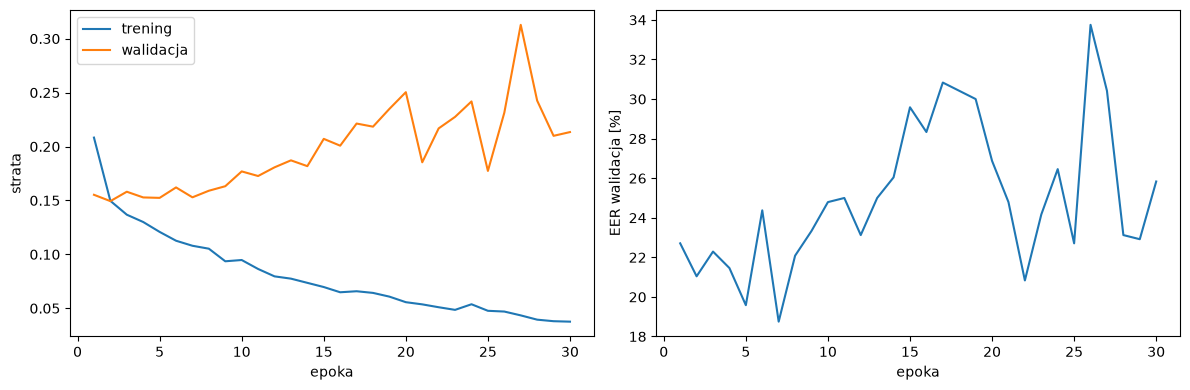

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs, history["train_loss"], label="trening")
axes[0].plot(epochs, history["val_loss"], label="walidacja")
axes[0].set_xlabel("epoka")
axes[0].set_ylabel("strata")
axes[0].legend()

axes[1].plot(epochs, [e * 100 for e in history["val_eer"]])
axes[1].set_xlabel("epoka")
axes[1].set_ylabel("EER walidacja [%]")

plt.tight_layout()
plt.show()

In [ ]:
from src.metrics import far_frr

model = SignatureNet().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

def network_scores(split, pair_types):
    ds = SignaturePairs(split, pair_types)
    loader = DataLoader(ds, batch_size=64, shuffle=False)
    distances, labels = [], []
    with torch.no_grad():
        for a, b, y in loader:
            distances.append(model(a.to(device), b.to(device)).cpu())
            labels.append(y)
    d = -torch.cat(distances).numpy()
    lab = torch.cat(labels).numpy()
    return d[lab == 1], d[lab == 0]

def baseline_scores(split, pair_types):
    ds = SignaturePairs(split, pair_types)
    s = np.array([np.corrcoef(ds.images[a].flatten(), ds.images[b].flatten())[0, 1] for a, b, _ in ds.pairs])
    lab = np.array([p[2] for p in ds.pairs])
    return s[lab == 1], s[lab == 0]

val_pos, val_neg = network_scores("val", ("genuine", "skilled"))
_, threshold = eer(val_pos, val_neg)
print(f"próg wybrany na walidacji: odległość {-threshold:.3f}\n")

for name, types in [("fałszerstwa wykwalifikowane", ("genuine", "skilled")),
                    ("fałszerstwa losowe", ("genuine", "random"))]:
    pos, neg = network_scores("test", types)
    net_eer, _ = eer(pos, neg)
    far, frr = far_frr(pos, neg, threshold)
    b_pos, b_neg = baseline_scores("test", types)
    base_eer, _ = eer(b_pos, b_neg)
    print(f"{name}:")
    print(f"  sieć:           EER {net_eer:.1%} | przy progu z walidacji: FAR {far:.1%}, FRR {frr:.1%}")
    print(f"  metoda bazowa:  EER {base_eer:.1%}")

próg wybrany na walidacji: odległość 0.529

fałszerstwa wykwalifikowane:
  sieć:           EER 25.4% | przy progu z walidacji: FAR 35.8%, FRR 15.8%
  metoda bazowa:  EER 45.7%
fałszerstwa losowe:
  sieć:           EER 13.8% | przy progu z walidacji: FAR 12.9%, FRR 15.8%
  metoda bazowa:  EER 30.8%


In [9]:
from src.dataset import ResampledPairs

history_base = history

torch.manual_seed(SEED)
train_set_rs = ResampledPairs("train")
train_loader_rs = DataLoader(train_set_rs, batch_size=32, shuffle=True)

MODEL_PATH_RS = Path("../models/siamese_resampled.pt")
model = SignatureNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

history = {"train_loss": [], "val_loss": [], "val_eer": []}
best_eer = 1.0

for epoch in range(1, EPOCHS + 1):
    train_set_rs.resample(epoch)
    train_loss = train_one_epoch(model, train_loader_rs, optimizer, MARGIN)
    val_loss, val_eer = evaluate(model, val_loader, MARGIN)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_eer"].append(val_eer)
    marker = ""
    if val_eer < best_eer:
        best_eer = val_eer
        torch.save(model.state_dict(), MODEL_PATH_RS)
        marker = "  <- najlepszy"
    print(f"epoka {epoch:2d}: strata trening {train_loss:.4f}, strata walidacja {val_loss:.4f}, "
          f"EER walidacja {val_eer:.1%}{marker}")

epoka  1: strata trening 0.2083, strata walidacja 0.1552, EER walidacja 22.7%  <- najlepszy
epoka  2: strata trening 0.1496, strata walidacja 0.1494, EER walidacja 21.0%  <- najlepszy
epoka  3: strata trening 0.1368, strata walidacja 0.1581, EER walidacja 22.3%
epoka  4: strata trening 0.1300, strata walidacja 0.1528, EER walidacja 21.5%
epoka  5: strata trening 0.1208, strata walidacja 0.1524, EER walidacja 19.6%  <- najlepszy
epoka  6: strata trening 0.1126, strata walidacja 0.1621, EER walidacja 24.4%
epoka  7: strata trening 0.1080, strata walidacja 0.1529, EER walidacja 18.8%  <- najlepszy
epoka  8: strata trening 0.1053, strata walidacja 0.1590, EER walidacja 22.1%
epoka  9: strata trening 0.0936, strata walidacja 0.1632, EER walidacja 23.3%
epoka 10: strata trening 0.0948, strata walidacja 0.1769, EER walidacja 24.8%
epoka 11: strata trening 0.0865, strata walidacja 0.1727, EER walidacja 25.0%
epoka 12: strata trening 0.0796, strata walidacja 0.1807, EER walidacja 23.1%
epoka 13